# Notebook 01 — Data Exploration
## Tokenization for Code-Switched and Mixed-Language Text

**Goal:** Explore code-switched datasets (English–Spanish, Hindi–English) to understand their structure, language distribution, and text statistics before running tokenization experiments.

## 1. Setup

In [16]:
import sys
sys.path.append("..")

from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams.update({"font.size": 12, "figure.dpi": 120})

print("Setup complete.")

Setup complete.


## 2. Load Datasets

Since the original LinCE benchmark uses a deprecated loading script on HuggingFace, we use alternative sources:

| Dataset | Source | Languages | Purpose |
|---------|--------|-----------|---------|
| CMU Hinglish DoG | `cmu_hinglish_dog` | Hindi–English (Romanized) | Real code-switched dialogue |
| WikiANN (EN) | `wikiann` | English | Monolingual NER baseline |
| WikiANN (ES) | `wikiann` | Spanish | Monolingual NER baseline |
| WikiANN (HI) | `wikiann` | Hindi | Monolingual NER baseline |
| Synthetic CS | Manual | Spanish–English | Hand-crafted code-switched examples |

### 2.1 Load Code-Switched and Multilingual Datasets

In [17]:
try:
    hinglish = load_dataset("cmu_hinglish_dog")
    print("Hindi-English dialogue loaded!")
    print(hinglish)
except Exception as e:
    print(f"cmu_hinglish_dog failed: {e}")
    hinglish = None

try:
    ner_en = load_dataset("wikiann", "en", split="train[:2000]")
    ner_es = load_dataset("wikiann", "es", split="train[:2000]")
    ner_hi = load_dataset("wikiann", "hi", split="train[:2000]")
    print(f"\nWikiANN loaded: EN={len(ner_en)}, ES={len(ner_es)}, HI={len(ner_hi)}")
except Exception as e:
    print(f"WikiANN failed: {e}")
    ner_en = ner_es = ner_hi = None

print("\nDone loading datasets.")

Hindi-English dialogue loaded!
DatasetDict({
    train: Dataset({
        features: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx'],
        num_rows: 8060
    })
    test: Dataset({
        features: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx'],
        num_rows: 960
    })
    validation: Dataset({
        features: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx'],
        num_rows: 942
    })
})

WikiANN loaded: EN=2000, ES=2000, HI=2000

Done loading datasets.


In [18]:
# Synthetic code-switched sentences for Spanish-English
# These are realistic examples typical of social media / bilingual speakers

with open("../data/cs_spanish_english.txt", encoding="utf-8") as f:
    cs_spaeng_texts = [line.strip() for line in f if line.strip()]

print(f"Spanish-English examples: {len(cs_spaeng_texts)}")
print(f"\nSample ES-EN: {cs_spaeng_texts[0]}")

Spanish-English examples: 40

Sample ES-EN: Hey, vamos to the store porque necesitamos milk.


### 2.2 Explore Hindi-English Dialogue Dataset

In [19]:
if hinglish is not None:
    print("Columns:", hinglish["train"].column_names)
    print(f"Train size: {len(hinglish['train'])}")
    print("\nFirst 3 examples:")
    for i in range(3):
        ex = hinglish["train"][i]
        print(f"\n--- Example {i+1} ---")
        for k, v in ex.items():
            val = str(v)[:200]
            print(f"  {k}: {val}")

Columns: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx']
Train size: 8060

First 3 examples:

--- Example 1 ---
  date: 2018-03-16T20:49:27.955Z
  docIdx: 0
  translation: {'en': 'hi', 'hi_en': 'hi'}
  uid: user1
  utcTimestamp: 2018-03-16T20:49:39.626Z
  rating: 2
  status: 1
  uid1LogInTime: 2018-03-16T20:49:27.955Z
  uid1LogOutTime: 2018-03-16T21:03:06.699Z
  uid1response: {'response': [1, 2, 3, 4], 'type': 'finish'}
  uid2response: {'response': [1, 4], 'type': 'finish'}
  user2_id: USR1533
  whoSawDoc: ['user2']
  wikiDocumentIdx: 14

--- Example 2 ---
  date: 2018-03-16T20:49:27.955Z
  docIdx: 0
  translation: {'en': 'what moviie did you see', 'hi_en': 'tumne konsi movie dekhi'}
  uid: user1
  utcTimestamp: 2018-03-16T20:50:25.612Z
  rating: 2
  status: 1
  uid1LogInTime: 2018-03-16T20:49:27.955Z
  uid1LogOutTime: 2018-03-16T21:03:06.699Z
  ui

In [20]:
if hinglish is not None:
    hinglish_texts = []
    for ex in hinglish["train"]:
        tr = ex.get("translation", {})
        hi_en = tr.get("hi_en", "")
        if isinstance(hi_en, str) and len(hi_en.split()) >= 3:
            hinglish_texts.append(hi_en)

    hinglish_texts = hinglish_texts[:2000]
    print(f"Extracted {len(hinglish_texts)} Hinglish utterances")
    print("\nSample utterances:")
    for t in hinglish_texts[:10]:
        print(f"  {t}")

Extracted 2000 Hinglish utterances

Sample utterances:
  tumne konsi movie dekhi
  hello tum kaise ho? Kya tumne Batman Begins ke bare mein suna hai? Kya great movie hai!
  nahi aur batao
  ye kis bare mein hai
  Isme Christian Bale, Michael Caine, and Liam Neeson starred hain. Great cast hain na?
  movie kis baare mein hai
  Ye kafi had tak Batman film franchise ka reboot hai nayi origin story ke saath. Christian Bale Batman play kar raha hai
  movie kitni lambi hai
  Film ke reviews kaafi acche hain. Sorry par i am not sure ki movie kitni lambi hai based on the given document.
  tum kya bolte ho movie ka genre kya hai?


In [21]:
if ner_en is not None:
    print("WikiANN columns:", ner_en.column_names)
    print(f"\nEN example: {ner_en[0]}")
    print(f"ES example: {ner_es[0]}")
    print(f"HI example: {ner_hi[0]}")

    tag_names = ner_en.features["ner_tags"].feature.names
    print(f"\nNER tags: {tag_names}")

    for name, ds in [("EN", ner_en), ("ES", ner_es), ("HI", ner_hi)]:
        all_tags = []
        for ex in ds:
            all_tags.extend(ex["ner_tags"])
        tag_counts = Counter(all_tags)
        total = sum(tag_counts.values())
        entity_count = total - tag_counts.get(0, 0)
        print(f"  {name}: {total} tokens, {entity_count} entity tokens ({entity_count/total*100:.1f}%)")

WikiANN columns: ['tokens', 'ner_tags', 'langs', 'spans']

EN example: {'tokens': ['R.H.', 'Saunders', '(', 'St.', 'Lawrence', 'River', ')', '(', '968', 'MW', ')'], 'ner_tags': [3, 4, 0, 3, 4, 4, 0, 0, 0, 0, 0], 'langs': ['en', 'en', 'en', 'en', 'en', 'en', 'en', 'en', 'en', 'en', 'en'], 'spans': ['ORG: R.H. Saunders', 'ORG: St. Lawrence River']}
ES example: {'tokens': ['REDIRECCIÓN', 'Algarrobo', '(', 'Chile', ')'], 'ner_tags': [0, 5, 6, 6, 6], 'langs': ['es', 'es', 'es', 'es', 'es'], 'spans': ['LOC: Algarrobo ( Chile )']}
HI example: {'tokens': ['टैपी', 'ने', 'अपने', 'उत्पादों', 'को', 'एशिया', 'के', 'अपतटीय', 'भागों', 'में', 'भेजने', 'का', 'फैसला', 'लिया।', 'उन्होंने', 'प्रोमोशन', 'के', 'लिए', 'मैडोना', 'को', 'अपने', 'साथ', 'मिलाया।'], 'ner_tags': [0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], 'langs': ['hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi'], 'spans': ['LOC: एशिय

In [22]:
all_spaeng_texts = cs_spaeng_texts
all_hineng_texts = hinglish_texts

print(f"Spanish-English texts: {len(all_spaeng_texts)}")
print(f"Hindi-English texts:   {len(all_hineng_texts)}")

if ner_en is not None:
    mono_en_texts = [" ".join(ex["tokens"]) for ex in ner_en][:500]
    mono_es_texts = [" ".join(ex["tokens"]) for ex in ner_es][:500]
    mono_hi_texts = [" ".join(ex["tokens"]) for ex in ner_hi][:500]
    print(f"\nMonolingual reference texts:")
    print(f"  English: {len(mono_en_texts)}")
    print(f"  Spanish: {len(mono_es_texts)}")
    print(f"  Hindi:   {len(mono_hi_texts)}")
else:
    mono_en_texts = mono_es_texts = mono_hi_texts = []
    print("WikiANN not loaded — no monolingual reference texts")


Spanish-English texts: 40
Hindi-English texts:   2000

Monolingual reference texts:
  English: 500
  Spanish: 500
  Hindi:   500


## 3. Language Distribution Analysis

We use `langid` to detect per-word language and see how languages mix within sentences.


In [23]:
import langid

def get_language_stats(texts, dataset_name):
    """Detect per-word language and return counts."""
    lang_counts = Counter()
    total_words = 0

    for text in texts[:500]:
        for word in text.split():
            if len(word) < 2:
                continue
            lang, _ = langid.classify(word)
            lang_counts[lang] += 1
            total_words += 1

    print(f"\n{dataset_name} — Per-word language distribution (top 10):")
    for lang, count in lang_counts.most_common(10):
        pct = count / total_words * 100
        print(f"  {lang}: {count:>6} ({pct:.1f}%)")

    return lang_counts

spaeng_langs = get_language_stats(all_spaeng_texts, "Spanish-English")
hineng_langs = get_language_stats(all_hineng_texts, "Hindi-English")


Spanish-English — Per-word language distribution (top 10):
  en:    278 (76.4%)
  es:     43 (11.8%)
  fr:      9 (2.5%)
  it:      5 (1.4%)
  de:      5 (1.4%)
  lt:      4 (1.1%)
  hu:      3 (0.8%)
  nl:      3 (0.8%)
  sv:      2 (0.5%)
  cs:      2 (0.5%)

Hindi-English — Per-word language distribution (top 10):
  en:   4968 (80.4%)
  de:    287 (4.6%)
  nl:    179 (2.9%)
  eu:    124 (2.0%)
  et:     96 (1.6%)
  zh:     82 (1.3%)
  es:     64 (1.0%)
  fi:     60 (1.0%)
  cs:     52 (0.8%)
  sv:     50 (0.8%)


NOTE: langid is unreliable for single-word classification, especially for Romanized Hindi which uses Latin script. Hindi words like 'tumne', 'dekhi', 'bahut' get misclassified as English, Dutch, Estonian, etc.
This is a known limitation — we will use a heuristic approach in the tokenizer comparison notebook instead.

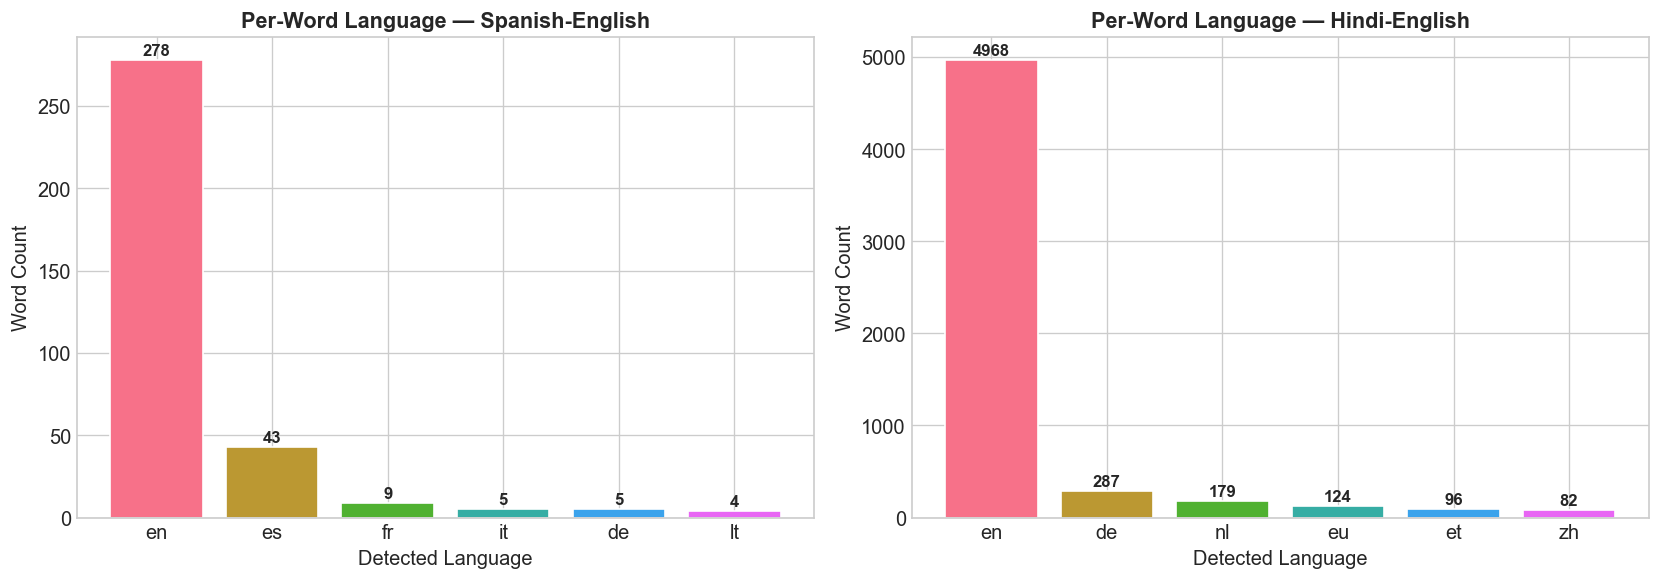

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (lang_counts, name) in zip(axes, [
    (spaeng_langs, "Spanish-English"),
    (hineng_langs, "Hindi-English"),
]):
    top = lang_counts.most_common(6)
    langs = [l for l, _ in top]
    counts = [c for _, c in top]
    colors = sns.color_palette("husl", len(langs))
    bars = ax.bar(langs, counts, color=colors, edgecolor="white")
    ax.set_title(f"Per-Word Language — {name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Detected Language")
    ax.set_ylabel("Word Count")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + max(counts)*0.01,
                f"{h}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Text Statistics

Sentence length and word count distributions across our datasets.


Spanish-English (synthetic):
  sentences=40, words/sent: mean=9.5, median=10, min=8, max=12
Hindi-English (real):
  sentences=2000, words/sent: mean=12.6, median=10, min=3, max=273
English (mono):
  sentences=500, words/sent: mean=8.3, median=6, min=3, max=45


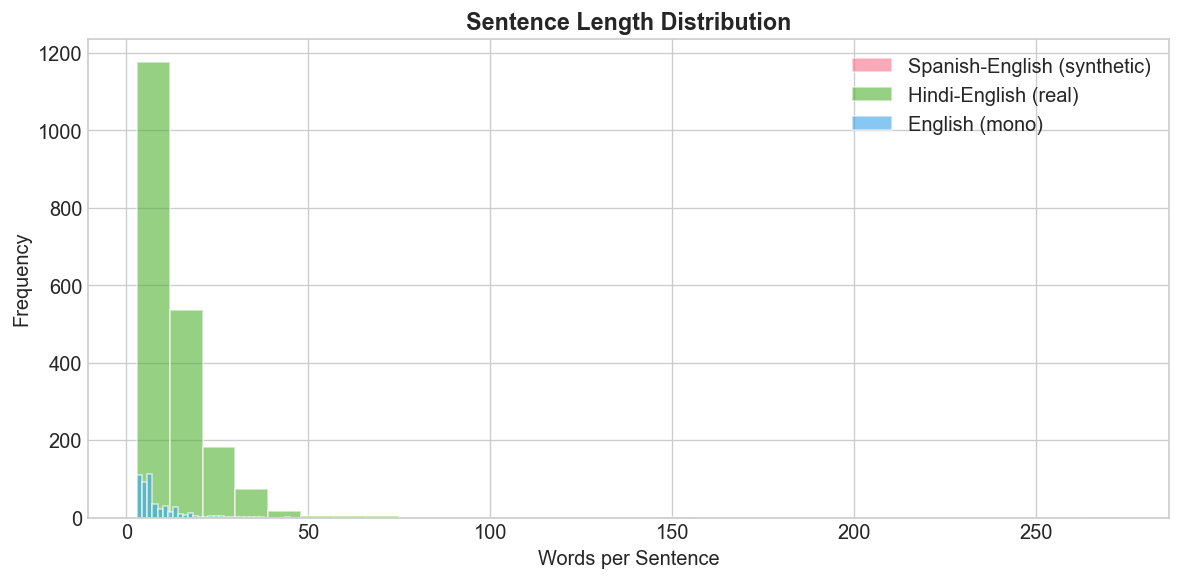

In [25]:
def text_stats(texts):
    word_counts = [len(t.split()) for t in texts]
    char_counts = [len(t) for t in texts]
    return pd.DataFrame({"word_count": word_counts, "char_count": char_counts})

stats = {
    "Spanish-English (synthetic)": text_stats(all_spaeng_texts),
    "Hindi-English (real)": text_stats(all_hineng_texts),
}
if mono_en_texts:
    stats["English (mono)"] = text_stats(mono_en_texts)

for name, df in stats.items():
    print(f"{name}:")
    print(f"  sentences={len(df)}, words/sent: mean={df.word_count.mean():.1f}, "
          f"median={df.word_count.median():.0f}, min={df.word_count.min()}, max={df.word_count.max()}")

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, df) in enumerate(stats.items()):
    ax.hist(df["word_count"], bins=30, alpha=0.6, label=name,
            color=sns.color_palette("husl", len(stats))[i], edgecolor="white")

ax.set_title("Sentence Length Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Words per Sentence")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Code-Switching Examples

Concrete examples showing where language switches happen within sentences.


In [26]:
def annotate_codeswitching(text):
    """Show each word with its detected language."""
    words = text.split()
    annotated = []
    for w in words:
        if len(w) < 2:
            annotated.append(f"{w}(?)")
            continue
        lang, _ = langid.classify(w)
        annotated.append(f"{w}[{lang}]")
    return " ".join(annotated)

print("SPANISH_ENGLISH EXAMPLES\n")
for i, t in enumerate(cs_spaeng_texts[:4]):
    print(f"[{i+1}] {t}")
    print(f"     {annotate_codeswitching(t)}\n")

print("\nHINDI_ENGLISH EXAMPLES\n")
for i, t in enumerate(hinglish_texts[:4]):
    print(f"[{i+1}] {t}")
    print(f"     {annotate_codeswitching(t)}\n")

SPANISH_ENGLISH EXAMPLES

[1] Hey, vamos to the store porque necesitamos milk.
     Hey,[en] vamos[es] to[en] the[en] store[en] porque[en] necesitamos[es] milk.[sv]

[2] I told María que no puedo ir a la fiesta tonight.
     I(?) told[en] María[es] que[en] no[en] puedo[es] ir[en] a(?) la[en] fiesta[en] tonight.[en]

[3] Ella said que tiene mucho homework para mañana.
     Ella[it] said[en] que[en] tiene[en] mucho[en] homework[en] para[en] mañana.[br]

[4] Can you pasar me the sal, por favor?
     Can[en] you[en] pasar[en] me[en] the[en] sal,[en] por[en] favor?[en]


HINDI_ENGLISH EXAMPLES

[1] tumne konsi movie dekhi
     tumne[en] konsi[en] movie[en] dekhi[en]

[2] hello tum kaise ho? Kya tumne Batman Begins ke bare mein suna hai? Kya great movie hai!
     hello[en] tum[en] kaise[fi] ho?[en] Kya[en] tumne[en] Batman[en] Begins[en] ke[en] bare[en] mein[de] suna[it] hai?[en] Kya[en] great[en] movie[en] hai![en]

[3] nahi aur batao
     nahi[eu] aur[en] batao[en]

[4] ye kis bare mein ha

## 6. Summary

### Key Observations:

1. **Real code-switching**: The Hindi-English dialogue data (CMU Hinglish DoG) shows natural code-switching — Hindi words (often Romanized) mixed freely with English within single sentences.

2. **Language detection is noisy**: `langid` on single words is imprecise (short words are ambiguous). The 80–85% "English" rate does not reflect actual language proportions — it is an artifact of weak single-word classification, especially for Romanized Hindi which shares Latin script with English.

3. **Script**: Most Hindi-English data uses Latin script (Romanized Hindi), which makes it harder for tokenizers to distinguish languages purely by character set.

4. **Sentence lengths**: Code-switched utterances tend to be short–medium (5–20 words), typical for conversational / social media data.

5. **WikiANN as monolingual baseline**: The WikiANN NER data (EN, ES, HI) is strictly monolingual — it serves as a reference point to compare how tokenizers behave on single-language text vs. code-switched text.

6. **Implications for tokenization**:
   - Monolingual English tokenizers will over-fragment Hindi/Spanish words
   - Monolingual Hindi/Spanish tokenizers will struggle with English words
   - Multilingual tokenizers (mBERT, XLM-R) should handle mixed input better